[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/2_qr%2Blstsq/2_qr%2Blstsq.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt
from math import *

# Optional: a library for plotting with LaTeX-like 
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

# Unit 2: QR factorization and least squares

## Lecture 14: Gram–Schmidt orthogonalization

### Code demo 1: Gram–Schmidt algorithms

We implement both the classical and modified Gram–Schmidt algorithms and explore their differences in numerical stability.

In [2]:
def cgs(A):
    """
    Compute the QR factorization of a matrix A using the classical Gram-Schmidt process.
    """
    m, n = A.shape
    v = np.zeros((m, n), dtype=np.float64)
    Q = np.zeros((m, n), dtype=np.float64)
    R = np.zeros((n, n), dtype=np.float64)

    for j in range(n):
        vj = A[:, j]
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            vj = vj - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(vj)
        Q[:, j] = vj / R[j, j]

    return Q, R

In [3]:
def mgs(A):
    """
    Compute the QR factorization of a matrix A using the modified Gram-Schmidt process.
    """
    m, n = A.shape
    v = np.zeros((m, n), dtype=np.float64)
    Q = np.zeros((m, n), dtype=np.float64)
    R = np.zeros((n, n), dtype=np.float64)

    for i in range(n):
        v[:, i] = A[:, i].copy()
    for i in range(n):
        R[i, i] = np.linalg.norm(v[:, i])
        Q[:, i] = v[:, i] / R[i, i]
        for j in range(i+1, n):
            R[i, j] = np.dot(Q[:, i], v[:, j])
            v[:, j] = v[:, j] - R[i, j] * Q[:, i]

    return Q, R

Let us first use `cgs` and `mgs` to compute QR factorization of a matrix, and compare it with library functions.

In [4]:
# Make a random matrix A
seed = 42
dim = 3
np.random.seed(seed) # set random seed for reproducibility
A = np.random.rand(dim, dim)

# QR with classical Gram-Schmidt
Q_cgs, R_cgs = cgs(A)
print(f'Q (CGS):\n{Q_cgs}\n')
print(f'R (CGS):\n{R_cgs}\n')
# QR with modified Gram-Schmidt
Q_mgs, R_mgs = mgs(A)
print(f'Q (MGS):\n{Q_mgs}\n')
print(f'R (MGS):\n{R_mgs}\n')
# QR with NumPy's built-in function
Q_np, R_np = np.linalg.qr(A)
print(f'Q (NumPy):\n{Q_np}\n')
print(f'R (NumPy):\n{R_np}\n')

# Check the orthogonality of Q
orthogonality_cgs = np.allclose(Q_cgs.T @ Q_cgs, np.eye(dim))
orthogonality_mgs = np.allclose(Q_mgs.T @ Q_mgs, np.eye(dim))
print(f'Orthogonality of Q (CGS): {orthogonality_cgs}')
print(f'Orthogonality of Q (MGS): {orthogonality_mgs}')

Q (CGS):
[[ 0.52859931  0.53175347  0.66168045]
 [ 0.84490405 -0.40485392 -0.34961472]
 [ 0.08197508  0.74386259 -0.66328616]]

R (CGS):
[[0.70855204 0.70537257 0.56800835]
 [0.         1.0866969  0.77323229]
 [0.         0.         0.03109683]]

Q (MGS):
[[ 0.52859931  0.53175347  0.66168045]
 [ 0.84490405 -0.40485392 -0.34961472]
 [ 0.08197508  0.74386259 -0.66328616]]

R (MGS):
[[0.70855204 0.70537257 0.56800835]
 [0.         1.0866969  0.77323229]
 [0.         0.         0.03109683]]

Q (NumPy):
[[-0.52859931  0.53175347 -0.66168045]
 [-0.84490405 -0.40485392  0.34961472]
 [-0.08197508  0.74386259  0.66328616]]

R (NumPy):
[[-0.70855204 -0.70537257 -0.56800835]
 [ 0.          1.0866969   0.77323229]
 [ 0.          0.         -0.03109683]]

Orthogonality of Q (CGS): True
Orthogonality of Q (MGS): True


Now let us examine the numerical stability of the two methods. We construct a matrix $A$ with random singular vectors and widely varying singular values spaced by factors of 2 between $2^{-1}$ and $2^{-80}$. Then, we use CGS and MGS to compute QR factorization of $A$.

In [5]:
# Make a random orthogonal matrix U
seed = 21
np.random.seed(seed)  # set random seed for reproducibility
U, _ = np.linalg.qr(np.random.rand(80, 80))
# Make a random orthogonal matrix V
seed = 16
np.random.seed(seed)  # set random seed for reproducibility
V, _ = np.linalg.qr(np.random.rand(80, 80))
# Make singular values from 2^-1 to 2^-80
S = np.diag(2.0**(-1*np.arange(1, 81, 1)))
# Construct A with SVD
A = U @ S @ V.T

In [6]:
# QR with classical Gram-Schmidt
Q_cgs, R_cgs = cgs(A)
# QR with modified Gram-Schmidt
Q_mgs, R_mgs = mgs(A)

Finally, we plot the diagonal elements $r_{jj}$ produced by both computations. Since $r_{jj} = \|P_j a_j\|$, this gives us a picture of the size of the projection at each step.

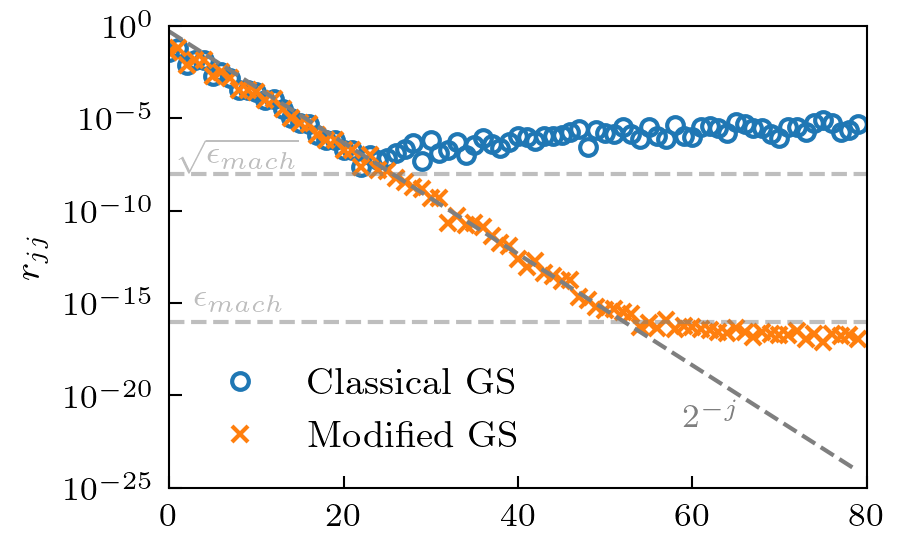

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)

# Plot singular values
ax.semilogy(np.diag(R_cgs), 'o', ms=4, color='tab:blue', mfc='none', label='Classical GS')
ax.semilogy(np.diag(R_mgs), 'x', ms=4, color='tab:orange', label='Modified GS')
# Plot errors and scaling line
fr = [2**(-k) for k in range(1, 81)]
ax.semilogy(fr, '--', color='tab:gray')
ax.hlines(1e-8, 0, 80, colors='tab:gray', linestyles='--', alpha=0.5)
ax.hlines(1e-16, 0, 80, colors='tab:gray', linestyles='--', alpha=0.5)

# Formatting
ax.set_ylabel('$r_{jj}$', fontsize=9)
ax.legend(loc='lower left', fontsize=9)
ax.text(8, 1e-8, '$\sqrt{\epsilon_{mach}}$', fontsize=8, color='tab:gray', ha='center', va='bottom', alpha=0.5)
ax.text(8, 10.0**(-15.5), '$\epsilon_{mach}$', fontsize=8, color='tab:gray', ha='center', va='bottom', alpha=0.5)
ax.text(62, 1e-22, '$2^{-j}$', fontsize=8, color='tab:gray', ha='center', va='bottom')
# Prettify
ax.set_xlim(0, 80)
ax.set_ylim(1e-25, 1)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/gram_schmidt.pdf', bbox_inches='tight', transparent=True)
plt.show()

The geometric decrease of $r_{jj}$ does not continue all the way to $j=80$. This is a consequence of rounding errors on the computer. With the classical Gram–Schmidt algorithm, the number never become smaller than about $10^{-8}$. With the modified Gram–Schmidt algorithm, they shrink eight orders of magnitude further, down to the order of $10^{-16}$, which is the level of machine epsilon for the computer.

The rounding error in classical Gram–Schmidt enters during the projection step. Each vector $a_j$ is orthogonalized by subtracting a linear combination of the previously computed $q_i$,
$$
v_j = a_j - \sum_{i=1}^{j-1} (q_i^{\mathsf{T}}a_j)q_i.
$$
In exact arithmetic, this removes all components of $a_j$ in the directions of the earlier $q_i$. However, in float point arithmetic, the compute vectors $q_i$ are only approximately orthogonal. When the projections are formed using the original $a_j$, small components in the directions of the earlier $q_i$ are not fully removed. These residual components are then carried into later steps and can be re-introduced by subsequent projections. This loss of orthogonality causes cancellation and limits how small $r_{jj}$ can become, producing the observed error floor around $10^{-8}$.

Modified Gram–Schmidt avoids this by updating the working vector after each projection,
$$
v_j^{(i+1)} = v_j^{(i)} - (q_i^{\mathsf{T}}a_j)q_i,
$$
so each coefficient is computed from the already deflated vector. This prevents previously removed components from reappearing and allows the diagonal entries $r_{jj}$ to decrease down to machine precision.

## Lecture 16: Least squares problem

### Code demo 1: Polynomial fit

Find least squares fit for degree-11 polynomial to 50 samples of $y=\cos(4x)$ for $x\in[0,1]$. Let us express the best-fit polynomial using the monomial basis:
$$
    p(x;b) = \sum_{k=0}^{11} b_k x^k.
$$
The $i$-th condition we would like to satisfy is
$$
    p(x_i; b) = \cos(4x_i)
$$
which is an overdetermined system with $50 \times 12$ Vandermonde matrix.

Condition number of A^T A: 1.3537545089937362e+16
Norm of difference between lstsq and normal equations: 0.20933172961944127
Residual norm (least squares): 7.999154657135022e-09
Residual norm (normal equations): 1.916512967644026e-08


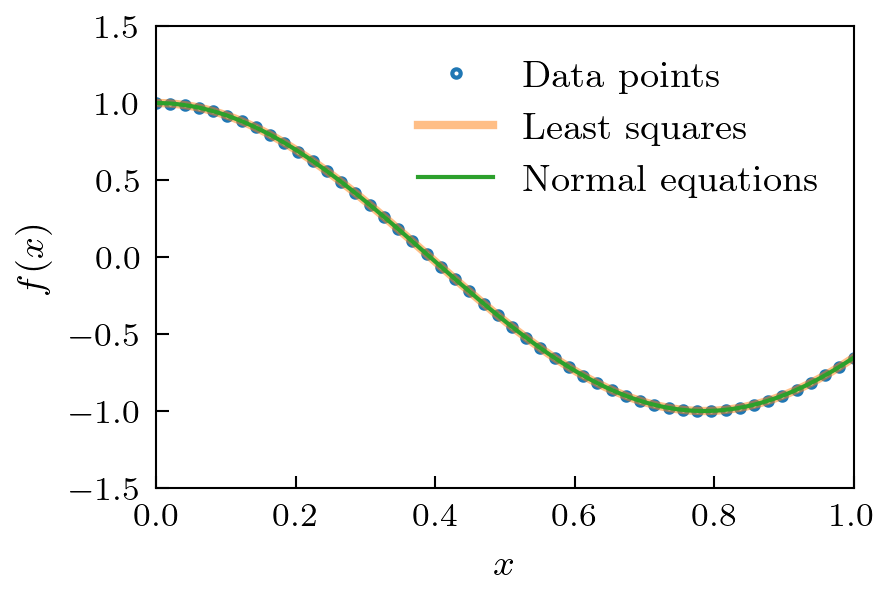

In [8]:
# Vandermonde interpolation function
n = 12
def vander_func(x, b):
    fx = 0
    for j in range(n):
        fx += b[j] * x**j
    return fx

# Create data and a truncated Vandermonde matrix
x = np.linspace(0, 1, 50)
A = np.vander(x, n, increasing=True)
y = np.cos(4.*x)

# Solve using the built-in least squares function
b_lstsq = np.linalg.lstsq(A, y, rcond=None)[0]

# Solve using the normal equations
AT = np.transpose(A)
ATA = AT @ A
print(f'Condition number of A^T A: {np.linalg.cond(ATA)}')
b_noreq = np.linalg.solve(ATA, AT @ y)

# Evaluate the difference between the two parameter sets
print(f'Norm of difference between lstsq and normal equations: {np.linalg.norm(b_lstsq - b_noreq)}')

# Calculate the residuals
residual_lstsq = np.linalg.norm(A @ b_lstsq - y)
residual_noreq = np.linalg.norm(A @ b_noreq - y)
print(f'Residual norm (least squares): {residual_lstsq}')
print(f'Residual norm (normal equations): {residual_noreq}')

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
xnew = np.linspace(0, 1, 200)
vnew_lstsq = [vander_func(x, b_lstsq) for x in xnew]
vnew_noreq = [vander_func(x, b_noreq) for x in xnew]
ax.plot(x, y, 'o', ms=2, color='tab:blue', mfc='none', label='Data points')
ax.plot(xnew, vnew_lstsq, '-', lw=2, alpha=0.5, color='tab:orange', label='Least squares')
ax.plot(xnew, vnew_noreq, '-', color='tab:green', label='Normal equations')
# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/lfit.pdf', bbox_inches='tight', transparent=True)
plt.show()

### Extra code: Polynomial fit with 11 data points

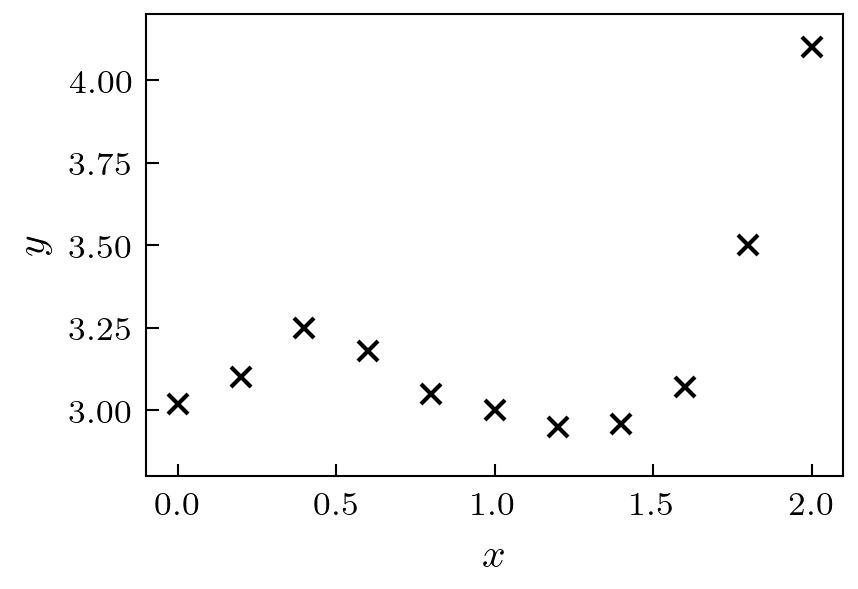

In [9]:
x = np.array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ])
y = np.array([3.02, 3.1, 3.25, 3.18, 3.05, 3.0, 2.95, 2.96, 3.07, 3.5, 4.1])

fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(x, y, 'x', ms=5, color='k')

xx = np.linspace(-0.1, 2.1, 100)
yy = 3.0 + 1.31 * xx - 2.27 * xx**2 + 0.93 * xx**3
# ax.plot(xx, yy, '-', color='tab:blue')

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

ax.set_xlim(-0.1, 2.1)
ax.set_ylim(2.8, 4.2)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)

# plt.savefig('results/poly_data.pdf', bbox_inches='tight', dpi=300)
# plt.savefig('results/poly_fit.pdf', bbox_inches='tight', dpi=300)
plt.show()

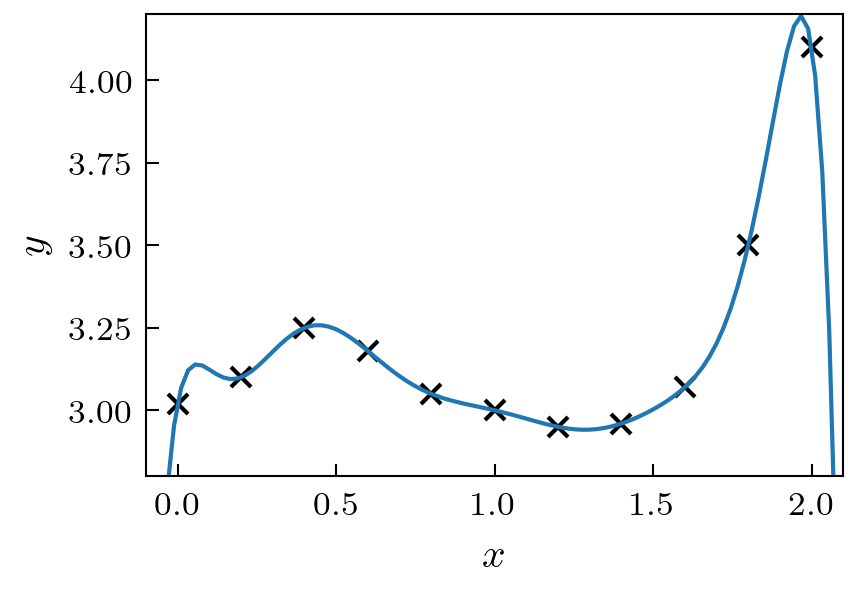

In [10]:
# degree-10 polynomial fit
V = np.vander(x, 11, increasing=True)
b = np.linalg.solve(V, y)
yy_fit = V @ b

fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(x, y, 'x', ms=5, color='k')

xx = np.linspace(-0.1, 2.1, 100)
yy = yy_fit[0] + b[1] * xx + b[2] * xx**2 + b[3] * xx**3 + b[4] * xx**4 + b[5] * xx**5 + b[6] * xx**6 + b[7] * xx**7 + b[8] * xx**8 + b[9] * xx**9 + b[10] * xx**10
ax.plot(xx, yy, '-', color='tab:blue')

# Formatting
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(-0.1, 2.1)
ax.set_ylim(2.8, 4.2)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)

# plt.savefig('results/poly_vander.pdf', bbox_inches='tight', dpi=300)
plt.show()

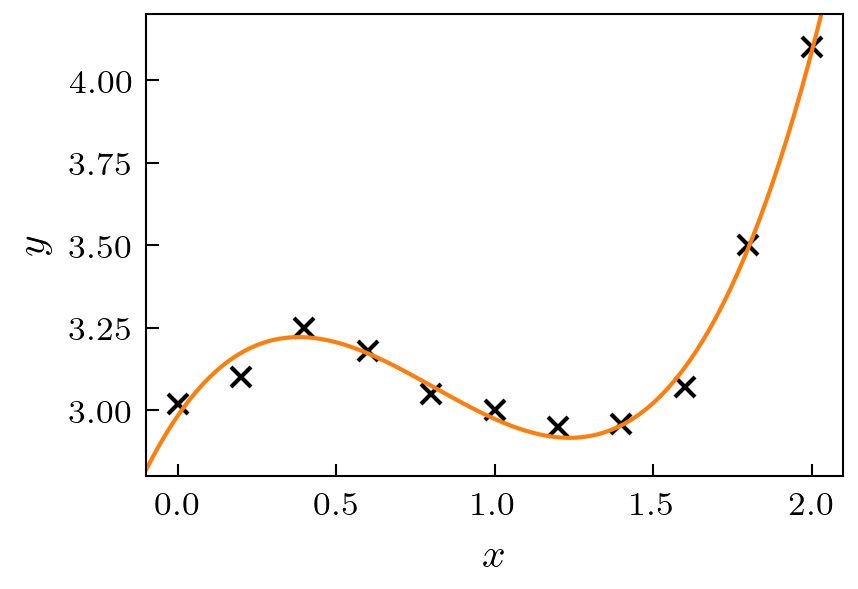

In [11]:
# degree-3 polynomial fit via least squares
V3 = np.vander(x, 4, increasing=True)  # Vandermonde
b3 = np.linalg.lstsq(V3, y, rcond=None)[0]
yy_fit3 = V3 @ b3

fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
ax.plot(x, y, 'x', ms=5, color='k')
xx = np.linspace(-0.1, 2.1, 100)
yy3 = b3[0] + b3[1] * xx + b3[2] * xx**2 + b3[3] * xx**3
ax.plot(xx, yy3, '-', color='tab:orange')

# Formatting
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_xlim(-0.1, 2.1)
ax.set_ylim(2.8, 4.2)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)

# plt.savefig('results/poly_cubic.pdf', bbox_inches='tight', dpi=300)
plt.show()

## (Extra) Lecture 17: Underdetermined least squares 

Find least squares fit for degree-11 polynomial to 5 samples of $y=\cos(4x)$ for $x\in[0,1]$.

12 parameters, 5 constraints $\implies$ $A \in \R^{5 \times 12}$ is short and wide, which is underdetermined.

We express the polynomial using the monomial basis, so that $A$ is a submatrix of the Vandermonde matrix.

### Option 1: The normal equations

If we naively use the normal equations, we see that $\text{cond}(A^\mathsf{T}T) = 4.2 \times 10^{18}$, i.e., "singular to machine precision"!


Condition number:  4.3819343637232573e+18
Normal eqs. : Norm(r):  6.822128317822419e-14


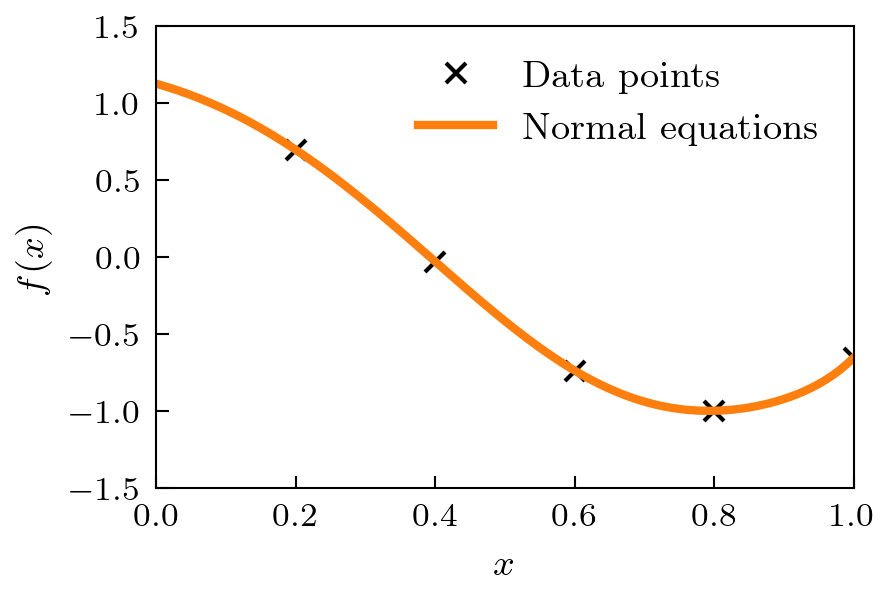

In [12]:
# Vandermonde interpolation function
n = 12 # degree-11
def vander_func(x, b):
    fx = 0
    for j in range(n):
        fx += b[j] * x**j
    return fx

# Construct rectangular Vandermonde matrix
x = np.linspace(0.2, 1, 5)
A = np.vander(x, n, increasing=True)
y = np.cos(4*x)

# Solve using the normal equations
AT = np.transpose(A)
ATA = np.dot(AT, A)
print('\nCondition number: ', np.linalg.cond(ATA))
b2 = np.linalg.solve(ATA, np.dot(AT, y))
print('Normal eqs. : Norm(r): ', np.linalg.norm(y-np.dot(A, b2)))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
xnew = np.linspace(0, 1, 200)
vnew = [vander_func(x, b2) for x in xnew]
ax.plot(x, y, 'x', ms=5, color='k', label='Data points')
ax.plot(xnew, vnew, '-', lw=2, color='tab:orange', label='Normal equations')
# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/under_lfit_normal.pdf', bbox_inches='tight', transparent=True)
plt.show()

### Option 2: The normal equations + regularization

We now regularize the problem with some different choices of $S$.

Let us try $S = 0.001 \mathbb{I}$ (i.e., $\mu = 0.001$).

We can see that the fit is good since regularization term is small but the condition number is large.


Condition number:  15336680.208343621
Normal eqs. : Norm(r):  0.00010688421978529812
Norm of b:  4.4013029912998505


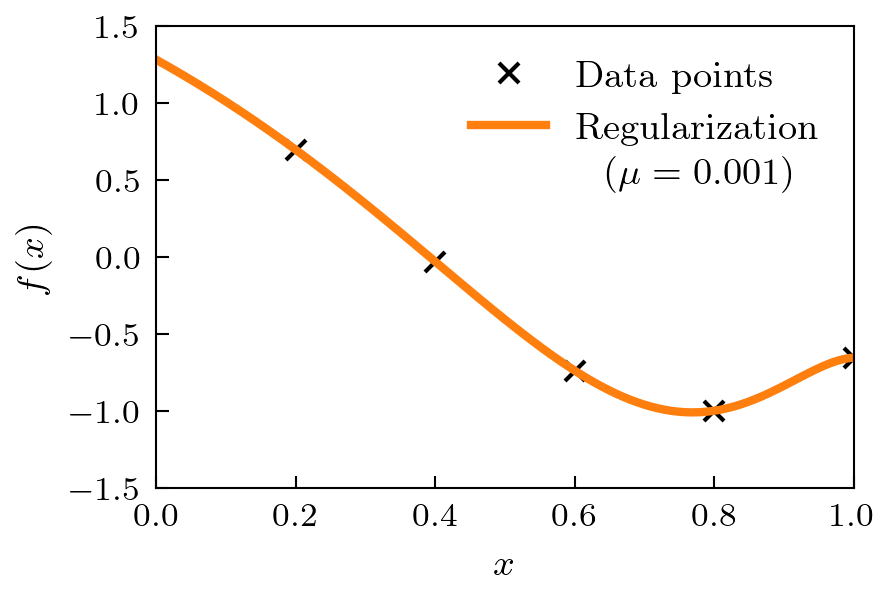

In [13]:
# Vandermonde interpolation function
n = 12  # degree-11
def vander_func(x, b):
    fx = 0
    for j in range(n):
        fx += b[j] * x**j
    return fx

# Construct rectangular Vandermonde matrix
x = np.linspace(0.2, 1, 5)
A = np.vander(x, n, increasing=True)
y = np.cos(4*x)

# Solve using normal equations + regularizer
mu = 0.001
S = np.identity(n) * mu
AT = np.transpose(A)
ATA = np.dot(AT, A)
ST = np.transpose(S)
STS = np.dot(ST, S)
print('\nCondition number: ', np.linalg.cond(ATA+STS))
b2 = np.linalg.solve(ATA+STS, np.dot(AT, y))
print('Normal eqs. : Norm(r): ', np.linalg.norm(y-np.dot(A, b2)))
print('Norm of b: ', np.linalg.norm(b2))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
xnew = np.linspace(0, 1, 200)
vnew = [vander_func(x, b2) for x in xnew]
ax.plot(x, y, 'x', ms=5, color='k', label='Data points')
ax.plot(xnew, vnew, '-', lw=2, color='tab:orange', label='Regularization')
# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.text(
    0.92, 0.72, '($\mu = 0.001$)',
    transform=ax.transAxes,
    ha='right', va='top', fontsize=9
)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/under_lfit_reg_001.pdf', bbox_inches='tight', transparent=True)
plt.show()

Let us try $S = 0.5 \mathbb{I}$ (i.e., $\mu = 0.5$).

Regularization term now dominates: Small condition number and small $\|b\|_2$, but poor fit to the data!


Condition number:  62.346716812029804
Normal eqs. : Norm(r):  0.6604499270460742
Norm of b:  1.1539346030587565


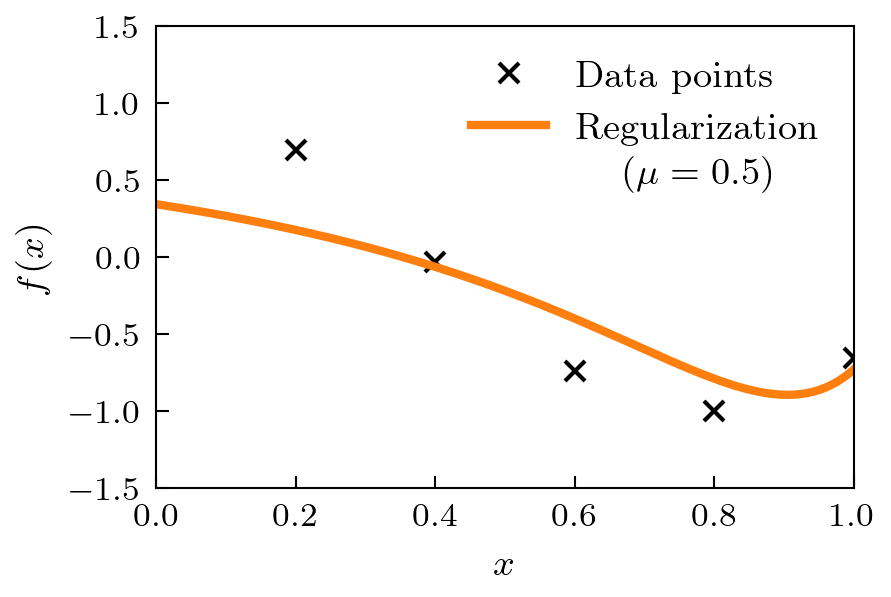

In [14]:
# Vandermonde interpolation function
n = 12  # degree-11
def vander_func(x, b):
    fx = 0
    for j in range(n):
        fx += b[j] * x**j
    return fx

# Construct rectangular Vandermonde matrix
x = np.linspace(0.2, 1, 5)
A = np.vander(x, n, increasing=True)
y = np.cos(4*x)

# Solve using normal equations + regularizer
mu = 0.5
S = np.identity(n) * mu
AT = np.transpose(A)
ATA = np.dot(AT, A)
ST = np.transpose(S)
STS = np.dot(ST, S)
print('\nCondition number: ', np.linalg.cond(ATA+STS))
b2 = np.linalg.solve(ATA+STS, np.dot(AT, y))
print('Normal eqs. : Norm(r): ', np.linalg.norm(y-np.dot(A, b2)))
print('Norm of b: ', np.linalg.norm(b2))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
xnew = np.linspace(0, 1, 200)
vnew = [vander_func(x, b2) for x in xnew]
ax.plot(x, y, 'x', ms=5, color='k', label='Data points')
ax.plot(xnew, vnew, '-', lw=2, color='tab:orange', label='Regularization')
# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.text(
    0.89, 0.72, '($\mu = 0.5$)',
    transform=ax.transAxes,
    ha='right', va='top', fontsize=9
)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/under_lfit_reg_5.pdf', bbox_inches='tight', transparent=True)
plt.show()

Try $S = \texttt{diag}(0.1, 0.1, 0.1, 10, 10, \ldots, 10)$.

We strongly penalize $b_3, b_4, \ldots, b_{11}$, hence the fit is close to parabolic.


Condition number:  5898.218418345133
Normal eqs. : Norm(r):  0.4775941679367557
Norm of b:  4.2675417792087025


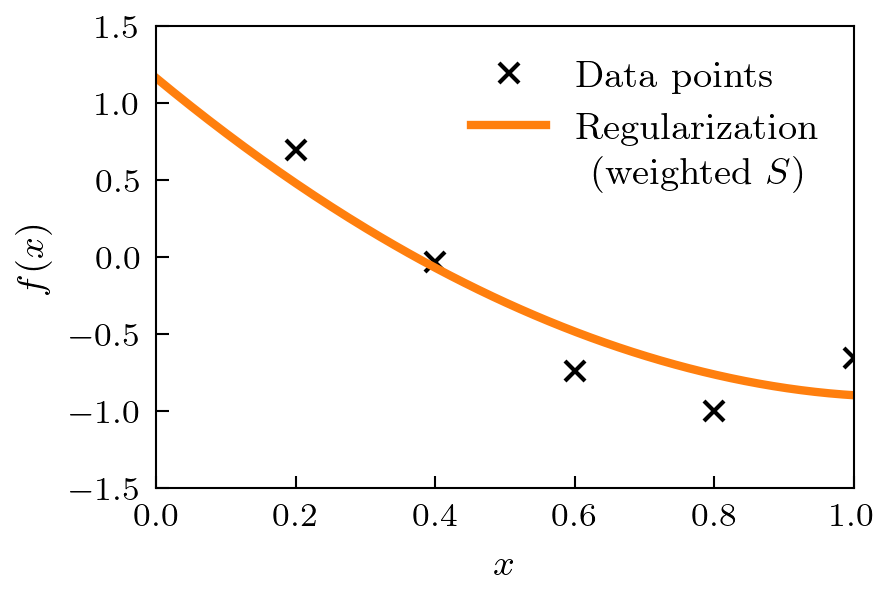

In [15]:
# Vandermonde interpolation function
n = 12  # degree-11
def vander_func(x, b):
    fx = 0
    for j in range(n):
        fx += b[j] * x**j
    return fx

# Construct rectangular Vandermonde matrix
x = np.linspace(0.2, 1, 5)
A = np.vander(x, n, increasing=True)
y = np.cos(4*x)

# Solve using normal equations + regularizer
mu = 10.
S = np.identity(n) * mu
S[0, 0] = 0.1
S[1, 1] = 0.1
S[2, 2] = 0.1
AT = np.transpose(A)
ATA = np.dot(AT, A)
ST = np.transpose(S)
STS = np.dot(ST, S)
print('\nCondition number: ', np.linalg.cond(ATA+STS))
b2 = np.linalg.solve(ATA+STS, np.dot(AT, y))
print('Normal eqs. : Norm(r): ', np.linalg.norm(y-np.dot(A, b2)))
print('Norm of b: ', np.linalg.norm(b2))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
xnew = np.linspace(0, 1, 200)
vnew = [vander_func(x, b2) for x in xnew]
ax.plot(x, y, 'x', ms=5, color='k', label='Data points')
ax.plot(xnew, vnew, '-', lw=2, color='tab:orange', label='Regularization')
# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.text(
    0.935, 0.72, '(weighted $S$)',
    transform=ax.transAxes,
    ha='right', va='top', fontsize=9
)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/under_lfit_reg_weighted.pdf', bbox_inches='tight', transparent=True)
plt.show()

### Option 3: Library function

lstsq solve : Norm(r):  6.797432870529399e-15
Norm of b:  4.403902706377028


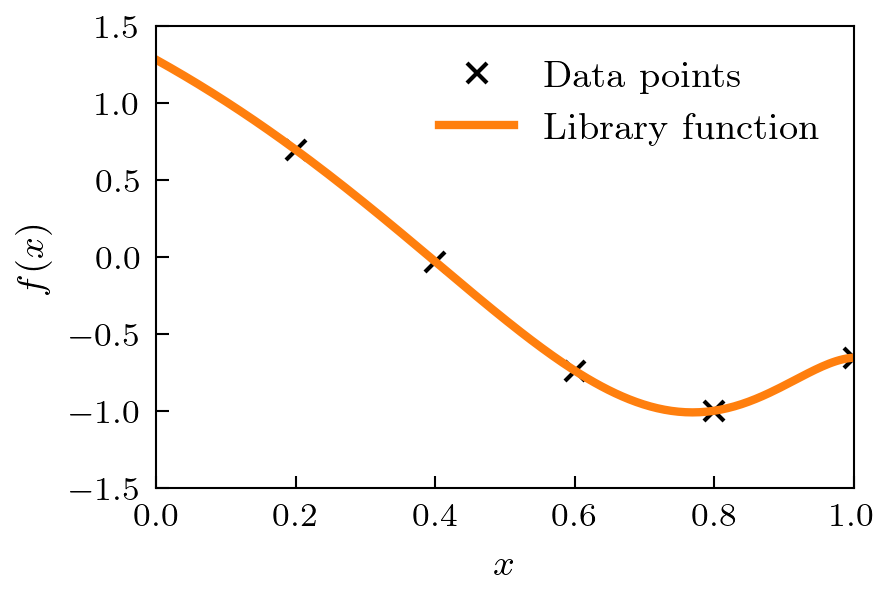

In [16]:
# Vandermonde interpolation function
n = 12  # degree-11
def vander_func(x, b):
    fx = 0
    for j in range(n):
        fx += b[j] * x**j
    return fx

# Construct rectangular Vandermonde matrix
x = np.linspace(0.2, 1, 5)
A = np.vander(x, n, increasing=True)
y = np.cos(4*x)

# Solve using least squares routine
b1=np.linalg.lstsq(A,y,rcond=None)[0]
print("lstsq solve : Norm(r): ",np.linalg.norm(y-np.dot(A,b1)))
print('Norm of b: ', np.linalg.norm(b1))

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)
xnew = np.linspace(0, 1, 200)
vnew = [vander_func(x, b1) for x in xnew]
ax.plot(x, y, 'x', ms=5, color='k', label='Data points')
ax.plot(xnew, vnew, '-', lw=2, color='tab:orange', label='Library function')
# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/under_lfit_lstsq.pdf', bbox_inches='tight', transparent=True)
plt.show()

### Summary

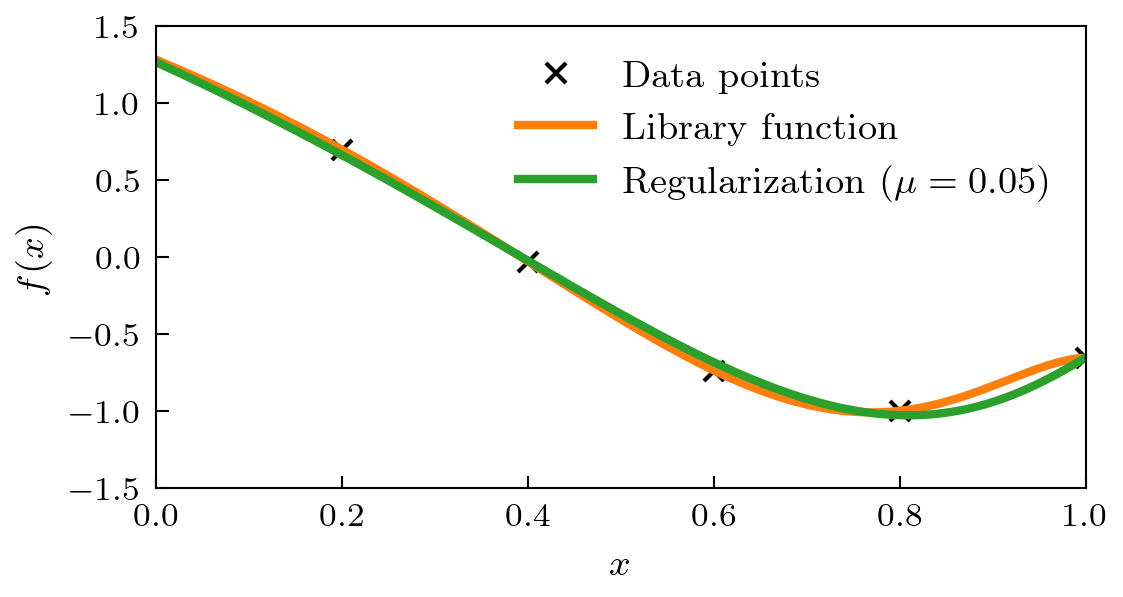

In [17]:
# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)
# Python least squares
xnew = np.linspace(0, 1, 200)
vnew = [vander_func(x, b1) for x in xnew]
ax.plot(x, y, 'x', ms=5, color='k', label='Data points')
ax.plot(xnew, vnew, '-', lw=2, color='tab:orange', label='Library function')
# Regularization mu = 0.05
mu = 0.05
S = np.identity(n) * mu
ATA = np.dot(AT, A)
ST = np.transpose(S)
STS = np.dot(ST, S)
b2 = np.linalg.solve(ATA+STS, np.dot(AT, y))
vnew_reg = [vander_func(x, b2) for x in xnew]
ax.plot(xnew, vnew_reg, '-', lw=2, color='tab:green', label='Regularization ($\mu=0.05$)')

# Formatting
ax.legend(loc='upper right', fontsize=9)
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$f(x)$', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(-1.5, 1.5)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/under_lfit_compare.pdf', bbox_inches='tight', transparent=True)
plt.show()